In [1]:
!pip install torch torchvision Pillow numpy pandas matplotlib scikit-learn
!pip install tensorflow matplotlib numpy scikit-learn seaborn

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
import urllib.request
import shutil
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [3]:
!mkdir -p data/waste_classification

url = 'https://github.com/garythung/trashnet/raw/master/data/dataset-resized.zip'
dataset_path = 'data/waste_classification/dataset-resized.zip'

if not os.path.exists(dataset_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, dataset_path)
    print("Download complete!")

extract_path = 'data/waste_classification/dataset-resized'
if not os.path.exists(extract_path):
    print("Extracting dataset...")
    with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
        zip_ref.extractall('data/waste_classification')
    print("Extraction complete!")

Download complete!
Extracting dataset...
Extraction complete!


In [4]:
print("Extracting dataset...")
with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall('data/waste_classification')
print("Extraction complete!")

data_dir = "data/waste_classification/dataset-resized"
print("Dataset directory:", data_dir)
print("Classes:", os.listdir(data_dir))

Extracting dataset...
Extraction complete!
Dataset directory: data/waste_classification/dataset-resized
Classes: ['glass', 'paper', '.DS_Store', 'cardboard', 'trash', 'metal', 'plastic']


In [5]:
AUGMENTATION_PARAMS = {
    'use_augmentation': True,
    'horizontal_flip_prob': 0.5,
    'rotation_degrees': 0.2,
    'color_jitter': {
        'brightness': 0.2,
        'contrast': 0.2,
        'saturation': 0.2,
        'hue': 0.1
    }
}

MODEL_PARAMS = {
    'conv_layers': 3,
    'initial_filters': 32,
    'filter_multiplier': 2,
    'kernel_size': 3,
    'dropout_rate': 0.5,
    'fc_units': 512
}

TRAINING_PARAMS = {
    'learning_rate': 0.001,
    'batch_size': 32,
    'epochs': 10,
    'image_size': (224, 224)

}

In [6]:
batch_size = TRAINING_PARAMS['batch_size']
img_size = TRAINING_PARAMS['image_size']

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [7]:
AUTOTUNE=tf.data.AUTOTUNE
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds=val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [8]:
if AUGMENTATION_PARAMS['use_augmentation']:
    data_augmentation = keras.Sequential(
        [
            layers.RandomFlip("horizontal",seed=123),
            layers.RandomRotation(AUGMENTATION_PARAMS['rotation_degrees'],seed=123),
            layers.RandomContrast(0.2,seed=123),
            layers.RandomBrightness(0.2,seed=123),
            layers.RandomZoom(0.2,seed=123)])
train_ds = train_ds.map(lambda x, y: (data_augmentation(x,training=True), y), num_parallel_calls=AUTOTUNE)

In [9]:
normalization_layer = layers.Rescaling(1./255)
normalized_train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y),num_parallel_calls=AUTOTUNE)
normalized_val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y),num_parallel_calls=AUTOTUNE)

In [18]:
def build_model(num_classes, image_size, params=MODEL_PARAMS):
    model = keras.Sequential()

    model.add(layers.Input(shape=(image_size[0], image_size[1], 3)))
    for i in range(params['conv_layers']):
        filters = params['initial_filters'] * (params['filter_multiplier'] ** i)
        model.add(layers.Conv2D(filters=filters,
                                 kernel_size=params['kernel_size'], padding='same', activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(params['fc_units'], activation='relu'))
    model.add(layers.Dropout(params['dropout_rate']))
    # Add the final classification layer
    model.add(layers.Dense(num_classes))

    return model

In [19]:
temp_ds = tf.keras.utils.image_dataset_from_directory(data_dir)
class_names = temp_ds.class_names
num_classes = len(class_names)
model = build_model(num_classes, img_size)
model.summary()

Found 2527 files belonging to 6 classes.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,477,958 (196.37 MB)

 Trainable params: 51,477,510 (196.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [20]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=TRAINING_PARAMS['learning_rate']),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [22]:
history = model.fit(normalized_train_ds, validation_data=normalized_val_ds, epochs=TRAINING_PARAMS['epochs'])

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 313s 5s/step - accuracy: 0.3487 - loss: 1.5623 - val_accuracy: 0.4396 - val_loss: 1.4067
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 301s 5s/step - accuracy: 0.3482 - loss: 1.5999 - val_accuracy: 0.2990 - val_loss: 2.0320
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 314s 5s/step - accuracy: 0.3620 - loss: 1.5541 - val_accuracy: 0.4574 - val_loss: 1.3808
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 299s 5s/step - accuracy: 0.3571 - loss: 1.5831 - val_accuracy: 0.4614 - val_loss: 1.3821
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 302s 5s/step - accuracy: 0.3620 - loss: 1.5514 - val_accuracy: 0.4277 - val_loss: 1.4258
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 310s 5s/step - accuracy: 0.3605 - loss: 1.5631 - val_accuracy: 0.3921 - val_loss: 1.4247
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 308s 5s/step - accuracy: 0.3576 - loss: 1.5377 - val_accuracy: 0.3406 - val_loss: 4.4354
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 298s 5s/step - accuracy: 0.3670 - loss: 1.5396 - val_accuracy: 0.4099 - v

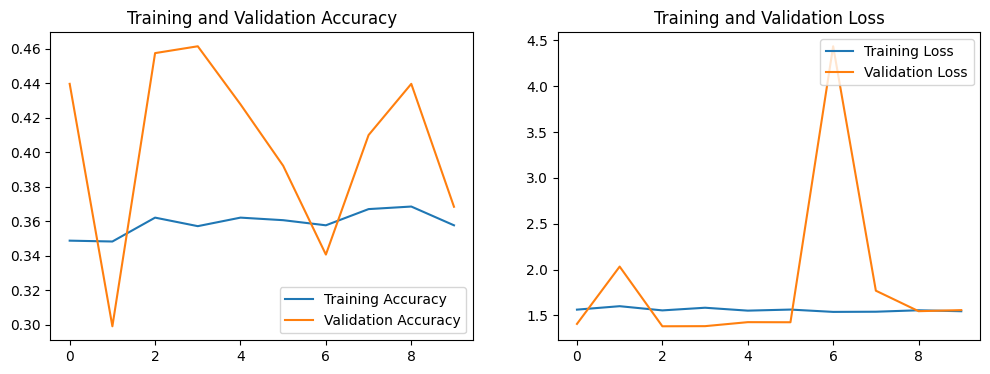

In [23]:
plot_training_history(history)

In [24]:
test_loss, test_accuracy = model.evaluate(normalized_val_ds, verbose=0)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

Test Loss: 1.5571
Test Accuracy: 0.3683


In [25]:
predictions = model.predict(normalized_val_ds)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = []
for images, labels in normalized_val_ds:
    true_classes.extend(labels.numpy())
true_classes = np.array(true_classes)

16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 771ms/step


In [26]:
report = classification_report(true_classes, predicted_classes, target_names=class_names)
print(report)

              precision    recall  f1-score   support

   cardboard       0.88      0.63      0.73        83
       glass       0.31      0.04      0.07       103
       metal       0.20      0.01      0.02        78
       paper       0.29      0.99      0.45       124
     plastic       0.75      0.07      0.12        88
       trash       0.00      0.00      0.00        29

    accuracy                           0.37       505
   macro avg       0.41      0.29      0.23       505
weighted avg       0.44      0.37      0.27       505



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


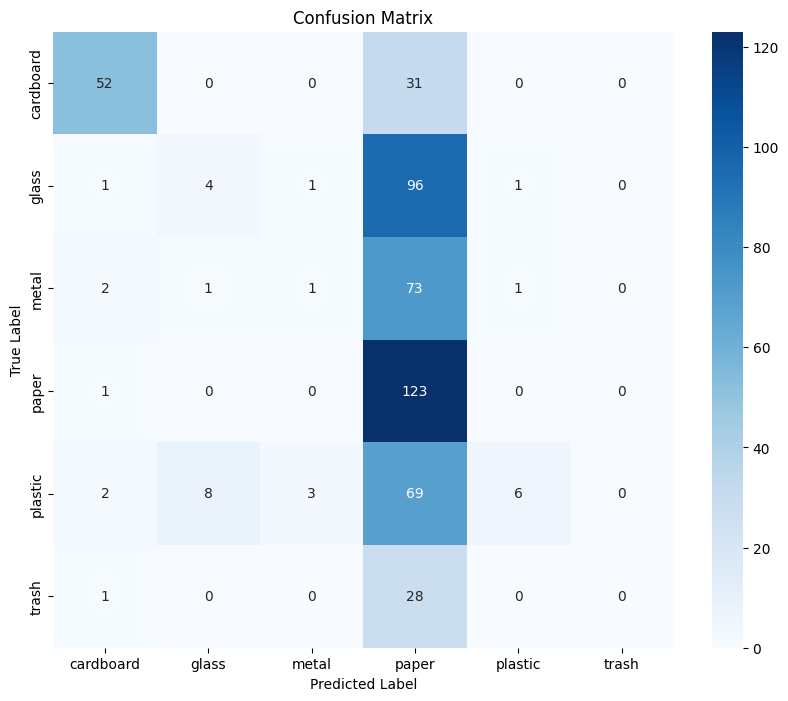

In [27]:
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


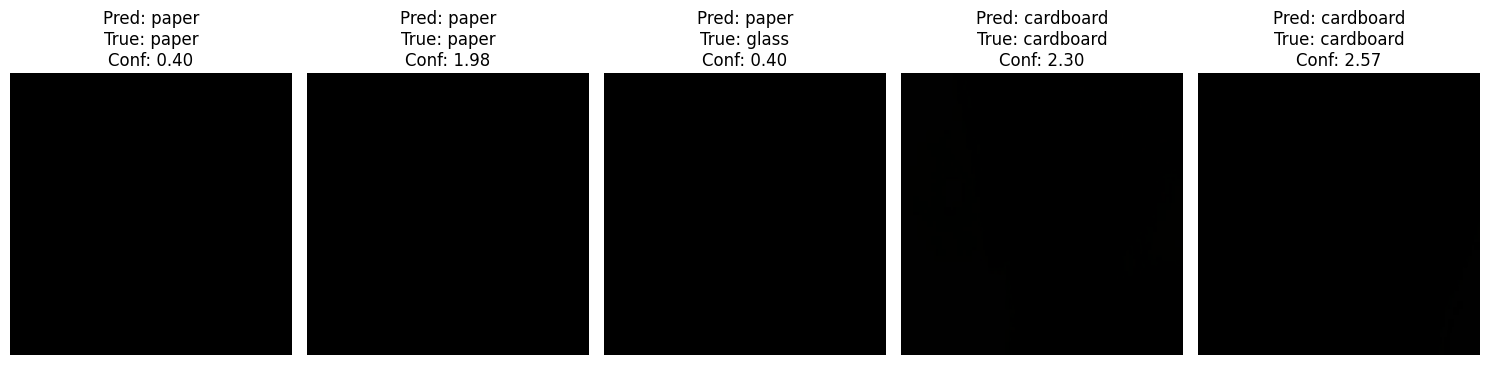

In [29]:
def visualize_predictions(model, dataset, class_names, num_images=5):
    plt.figure(figsize=(15, 6))

    for images, labels in dataset.take(1):
        predictions = model.predict(images)

        for i in range(num_images):
            ax = plt.subplot(1, num_images, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))

            predicted_class = class_names[np.argmax(predictions[i])]
            true_class = class_names[labels[i]]
            confidence = np.max(predictions[i])

            plt.title(f'Pred: {predicted_class}\nTrue: {true_class}\nConf: {confidence:.2f}')
            plt.axis('off')

    plt.tight_layout()
    plt.show()

visualize_predictions(model, normalized_val_ds, class_names)